GRADIENT DESCENT

In [ ]:
import numpy as np
import time
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Load Diabetes Dataset
# ----------------------------
data = load_diabetes()
X = data.data
y = data.target

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Add bias term
X = np.c_[np.ones(X.shape[0]), X]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# Mean Squared Error
# ----------------------------
def mse(X, y, theta):
    predictions = X @ theta
    return np.mean((predictions - y) ** 2)

# ----------------------------
# Batch Gradient Descent
# ----------------------------
def batch_gd(X, y, lr=0.01, epochs=100):
    m, n = X.shape
    theta = np.zeros(n)
    updates = 0

    start = time.time()

    for _ in range(epochs):
        gradient = (2/m) * X.T @ (X @ theta - y)
        theta -= lr * gradient
        updates += 1

    end = time.time()

    return theta, updates, end-start, mse(X, y, theta)

# ----------------------------
# Stochastic Gradient Descent
# ----------------------------
def sgd(X, y, lr=0.01, epochs=100):
    m, n = X.shape
    theta = np.zeros(n)
    updates = 0

    start = time.time()

    for _ in range(epochs):
        for i in range(m):
            xi = X[i:i+1]
            yi = y[i]

            gradient = 2 * xi.T @ (xi @ theta - yi)
            theta -= lr * gradient.flatten()
            updates += 1

    end = time.time()

    return theta, updates, end-start, mse(X, y, theta)

# ----------------------------
# Mini-Batch Gradient Descent
# ----------------------------
def mini_batch_gd(X, y, batch_size=64, lr=0.01, epochs=100):
    m, n = X.shape
    theta = np.zeros(n)
    updates = 0

    start = time.time()

    for _ in range(epochs):
        for i in range(0, m, batch_size):
            xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]

            gradient = (2/len(xb)) * xb.T @ (xb @ theta - yb)
            theta -= lr * gradient
            updates += 1

    end = time.time()

    return theta, updates, end-start, mse(X, y, theta)

# ----------------------------
# Train Models
# ----------------------------
theta1, upd1, time1, loss1 = batch_gd(X_train, y_train)
theta2, upd2, time2, loss2 = sgd(X_train, y_train)
theta3, upd3, time3, loss3 = mini_batch_gd(X_train, y_train)

# ----------------------------
# Display Results
# ----------------------------
print("\nComparison of Gradient Descent Methods\n")

print(f"{'Optimizer':<20}{'Time(s)':<12}{'Updates':<12}{'Final Loss'}")
print("-"*60)

print(f"{'Batch GD':<20}{time1:<12.4f}{upd1:<12}{loss1:.4f}")
print(f"{'SGD':<20}{time2:<12.4f}{upd2:<12}{loss2:.4f}")
print(f"{'Mini-Batch GD':<20}{time3:<12.4f}{upd3:<12}{loss3:.4f}")

print("\nConclusion:")
print("Mini-Batch Gradient Descent provides a good balance")
print("between execution time, parameter updates, and convergence.")


Comparison of Gradient Descent Methods

Optimizer           Time(s)     Updates     Final Loss
------------------------------------------------------------
Batch GD            0.0010      100         3314.7827
SGD                 0.2369      35300       3147.6633
Mini-Batch GD       0.0038      600         2900.1366

Conclusion:
Mini-Batch Gradient Descent provides a good balance
between execution time, parameter updates, and convergence.


OPTIMIZERS

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training with SGD_Momentum


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8794 - loss: 0.4242 - val_accuracy: 0.9300 - val_loss: 0.2503
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9357 - loss: 0.2287 - val_accuracy: 0.9480 - val_loss: 0.1905
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9499 - loss: 0.1744 - val_accuracy: 0.9564 - val_loss: 0.1583
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9597 - loss: 0.1428 - val_accuracy: 0.9613 - val_loss: 0.1367
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9654 - loss: 0.1198 - val_accuracy: 0.9652 - val_loss: 0.1234
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9707 - loss: 0.1036 - val_accuracy: 0.9671 - val_loss: 0.1121
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9745 - loss: 0.0910 - val_accuracy: 0.9668 - val_loss: 0.1084
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9779 - loss: 0.0806 - val_accuracy: 0.

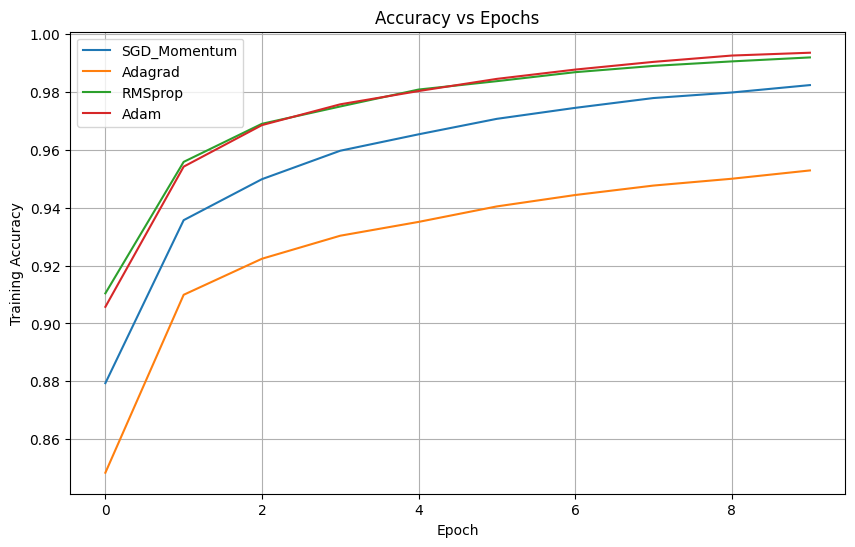

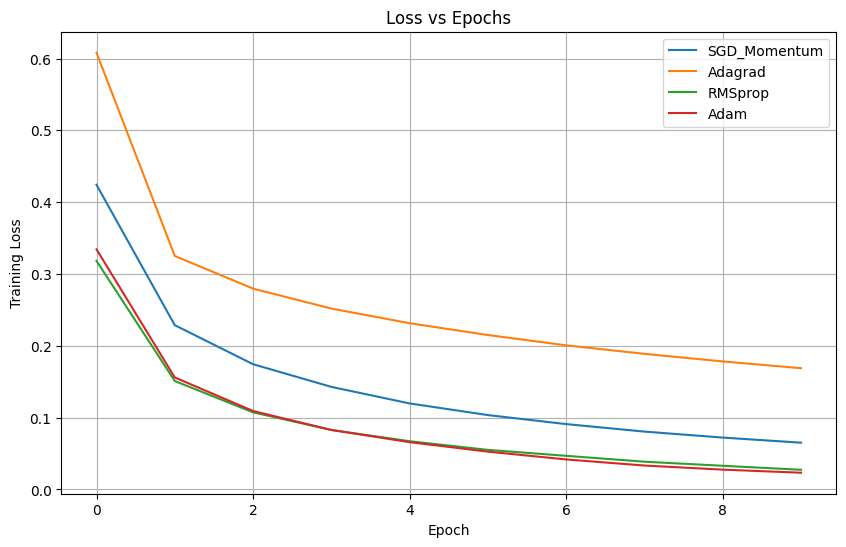


Final Comparison

Optimizer      Train Acc      Val Acc        Train Loss     Val Loss       
SGD_Momentum   0.9824         0.9737         0.0651         0.0894         
Adagrad        0.9529         0.9545         0.1688         0.1695         
RMSprop        0.9919         0.9758         0.0274         0.0932         
Adam           0.9936         0.9764         0.0233         0.0848         


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocessing
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

# Function to create model
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Optimizers
optimizers = {
    "SGD_Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=0.01),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

histories = {}

# Train using each optimizer
for name, optimizer in optimizers.items():
    print(f"\nTraining with {name}")

    model = create_model()

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    print(f"Test Accuracy ({name}): {test_acc:.4f}")

    histories[name] = history

#Accuracy vs Epochs
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['accuracy'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

#Loss vs Epochs
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['loss'], label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

print("\nFinal Comparison\n")

print("{:<15}{:<15}{:<15}{:<15}{:<15}".format(
    "Optimizer",
    "Train Acc",
    "Val Acc",
    "Train Loss",
    "Val Loss"))

#Print Final Results
for name, history in histories.items():

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    print("{:<15}{:<15.4f}{:<15.4f}{:<15.4f}{:<15.4f}".format(
        name,
        train_acc,
        val_acc,
        train_loss,
        val_loss
    ))